# 20 — Evaluate Text Model

Loads the best checkpoint for each trained model and runs full test-set
evaluation: classification report, confusion matrix, and inference speed.

**Depends on:** `01_preprocess_text.ipynb` (run automatically below).

**Reads from** `../experiments/text_unimodal/<version>/<model_slug>/model/`.

**Writes to each run directory:**
- `classification_report_test.json`
- `confusion_matrix_test.png`
- `eval_metrics.json` — full test metrics + inference speed

In [1]:
# Imports train_df, dev_df, test_df, label2id, id2label, labels_sorted
%run 01_preprocess_text.ipynb

e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\.venv\Lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Label map: {'anger': 0, 'disgust': 1, 'fear': 2, 'happiness': 3, 'neutral': 4, 'sadness': 5, 'surprise': 6}
Train: 9,989 | Dev: 1,109 | Test: 2,610
Dropped from dev (unseen labels): 0
Dropped from test (unseen labels): 0
[train] OK — 9,989 rows, dtypes: {'text': <StringDtype(na_value=nan)>, 'emotion': <StringDtype(na_value=nan)>, 'label': dtype('int32')}
[dev] OK — 1,109 rows, dtypes: {'text': <StringDtype(na_value=nan)>, 'emotion': <StringDtype(na_value=nan)>, 'label': dtype('int32')}
[test] OK — 2,610 rows, dtypes: {'text': <StringDtype(na_value=nan)>, 'emotion': <StringDtype(na_value=nan)>, 'label': dtype('int32')}


In [2]:
import os
import json
import pandas as pd

from src.config import EXP_ROOT, VERSION, MODELS_TO_RUN, DEVICE
from src.training.utils import slugify, write_json
from src.evaluation.evaluate import run_full_evaluation

## Discover run directories

We look for the first (non-`__run*`) run directory for each model.
Change `run_dirs` manually if you want to evaluate a specific run.

In [3]:
def find_run_dir(model_name: str) -> str:
    """Return the primary run directory for a model (no __run* suffix)."""
    slug = slugify(model_name)
    path = os.path.join(EXP_ROOT, VERSION, slug)
    assert os.path.isdir(path), f'Run directory not found: {path}\nRun 10_train_text_model.ipynb first.'
    return path

run_dirs = [find_run_dir(m) for m in MODELS_TO_RUN]
print('Evaluating:', run_dirs)

Evaluating: ['../experiments/text_unimodal\\v1\\bert_base_uncased', '../experiments/text_unimodal\\v1\\distilbert_base_uncased']


## Run evaluation

In [4]:
all_results = {}

for model_name, run_dir in zip(MODELS_TO_RUN, run_dirs):
    print(f'\n=== {model_name} ===')
    results = run_full_evaluation(
        run_dir=run_dir,
        test_df=test_df,
        id2label=id2label,
        device=DEVICE,
    )
    all_results[model_name] = results
    write_json(os.path.join(run_dir, 'eval_metrics.json'), results)

    print(f'  Accuracy    : {results["accuracy"]:.4f}')
    print(f'  Macro F1    : {results["macro_f1"]:.4f}')
    print(f'  Weighted F1 : {results["weighted_f1"]:.4f}')
    print(f'  Infer ms/sample (bs=1): {results["inference_ms_per_sample_bs1"]:.2f}')


=== bert-base-uncased ===


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 797.80it/s, Materializing param=classifier.weight]                                      


  Accuracy    : 0.6165
  Macro F1    : 0.4428
  Weighted F1 : 0.6085
  Infer ms/sample (bs=1): 11.55

=== distilbert-base-uncased ===


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 867.80it/s, Materializing param=pre_classifier.weight]                                  


  Accuracy    : 0.5877
  Macro F1    : 0.4123
  Weighted F1 : 0.5885
  Infer ms/sample (bs=1): 5.82


## Side-by-side summary

In [5]:
summary = pd.DataFrame([
    {
        'model':        name,
        'accuracy':     r['accuracy'],
        'macro_f1':     r['macro_f1'],
        'weighted_f1':  r['weighted_f1'],
        'infer_ms_bs1': r['inference_ms_per_sample_bs1'],
    }
    for name, r in all_results.items()
])
summary

,model,accuracy,macro_f1,weighted_f1,infer_ms_bs1
0,bert-base-uncased,0.616475,0.442810,0.608548,11.553073
1,distilbert-base-uncased,0.587739,0.412274,0.588522,5.824770


## Confusion matrices

Figures are already saved to each run directory. Display them here inline.

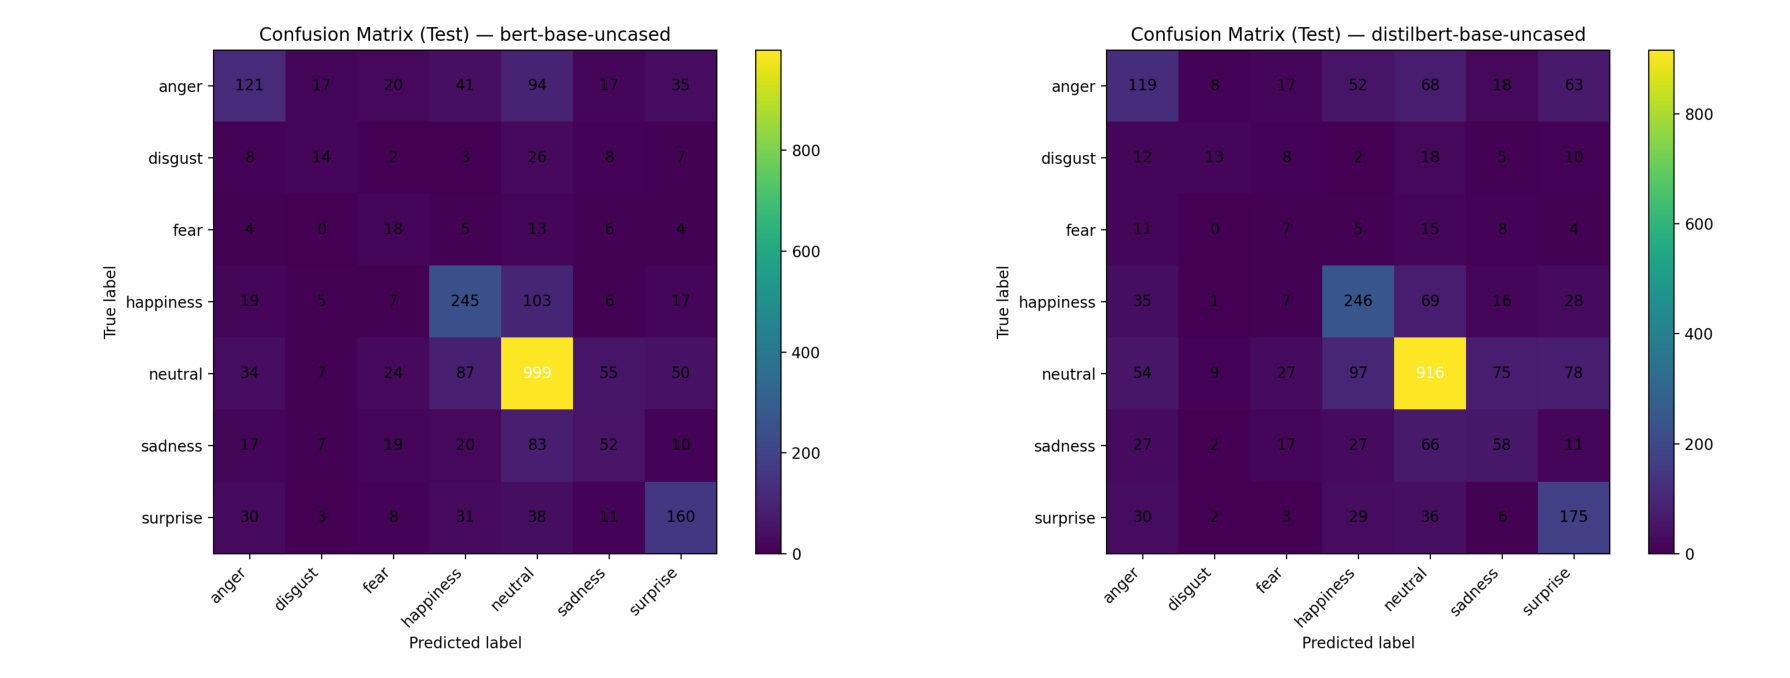

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, len(run_dirs), figsize=(9 * len(run_dirs), 7), squeeze=False)

for ax, run_dir in zip(axes[0], run_dirs):
    img_path = os.path.join(run_dir, 'confusion_matrix_test.png')
    if os.path.exists(img_path):
        ax.imshow(mpimg.imread(img_path))
    ax.axis('off')

plt.tight_layout()
plt.show()